In [41]:
import pandas as pd
import re
from datetime import datetime
import os
import seaborn as sns

In [42]:
# Diccionario para convertir meses en español a número (o inglés)
meses_espanol = {
    "ENE": "01", "FEB": "02", "MAR": "03", "ABR": "04", "MAY": "05", "JUN": "06",
    "JUL": "07", "AGO": "08", "SEP": "09", "OCT": "10", "NOV": "11", "DIC": "12"
}

In [50]:
def parse_weather_file(file_path):
    # Leer el archivo
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
    

    fecha_str = file_path.split("\\")[1][4:12]  # "20241011"
    # Convertir a datetime
    fecha_archivo = datetime.strptime(fecha_str, "%Y%m%d").date()  # 2024-10-11
    # Separar por estaciones
    stations = re.split(r'\n([A-Z_]+)\n', content)[1:]
    
    data = []
    
    for i in range(0, len(stations), 2):
        station_name = stations[i]
        station_data = stations[i+1]
        
        for line in station_data.split('\n'):
            if re.match(r'^\s*\d{2}/[A-Z]{3}/\d{4}', line):
                # Limpiar y dividir la línea
                clean_line = re.sub(r'\s{2,}', '|', line.strip())
                parts = clean_line.split('|')
                # Manejar líneas con formato inconsistente
                if len(parts) >= 4:
                    try:
                        fecha_hora = parts[0]
                        temperatura = parts[1]
                        viento = parts[2]
                        precipitacion = parts[4] if len(parts) > 3 else '0.0'
                        
                        # Separar dirección y velocidad del viento
                        viento_parts = viento.split('|')
                        if len(viento_parts) == 2:
                            dir_viento, vel_viento = viento_parts
                        else:
                            # Si no se puede separar, usar valores por defecto
                            dir_viento = viento_parts[0] if viento_parts else '0'
                            vel_viento = '0'
                        
                        # Limpiar valores
                        dir_viento = dir_viento.strip()
                        vel_viento = vel_viento.strip()
                        
                        # Manejar valores vacíos
                        dir_viento = dir_viento if dir_viento else '0'
                        vel_viento = vel_viento if vel_viento else '0'
                        
                        # Extraer fecha y hora
                        dia, mes, resto = fecha_hora.split("/")
                        anio, hora = resto.split()  # Separa "2024" y "00Hs."
                        # Obtener el mes en formato numérico
                        mes_num = meses_espanol[mes]

                        # Reconstruir la fecha en formato estándar (sin "Hs.")
                        nueva_fecha_str = f"{dia}/{mes_num}/{anio} {hora.replace('Hs.', '')}"

                        # Convertir a datetime (formato: día/mes/año hora)
                        fecha_dt = datetime.strptime(nueva_fecha_str, "%d/%m/%Y %H")
                        if fecha_dt.date() == fecha_archivo:
                            data.append({
                                'Estacion': station_name,
                                'FechaHora': fecha_dt,
                                'Temperatura': float(temperatura) if temperatura else 0.0,
                            })
                    except Exception as e:
                        print(f"Error procesando línea: {line}")
                        print(f"Error: {str(e)}")
                        continue
    
    # Crear DataFrame
    df = pd.DataFrame(data)
    
    return df

In [53]:
output_path = "datos_meteorologicos.csv"
for file in os.listdir("observaciones_2024/"):
    weather_df = parse_weather_file(os.path.join("observaciones_2024", file))
    # Guardar como CSV
    weather_df.to_csv(output_path, index=False, mode='a', header=not os.path.exists(output_path))

In [57]:
df = pd.read_csv("datos_meteorologicos.csv")
df["FechaHora"] = pd.to_datetime(df["FechaHora"])
df = df[(df["Estacion"]== 'AEROPARQUE') & (df["FechaHora"].dt.hour == 15)]

In [58]:
df

,Estacion,FechaHora,Temperatura
5,AEROPARQUE,2024-01-01 15:00:00,26.9
949,AEROPARQUE,2024-01-02 15:00:00,25.3
1893,AEROPARQUE,2024-01-03 15:00:00,25.2
2837,AEROPARQUE,2024-01-04 15:00:00,27.5
3781,AEROPARQUE,2024-01-05 15:00:00,30.0
...,...,...,...
331373,AEROPARQUE,2024-12-27 15:00:00,28.1
332317,AEROPARQUE,2024-12-28 15:00:00,27.0
333261,AEROPARQUE,2024-12-29 15:00:00,25.9
334205,AEROPARQUE,2024-12-30 15:00:00,28.3


In [60]:
df.to_parquet("pronostico_temperatura.parquet")

<Axes: xlabel='FechaHora', ylabel='Temperatura'>

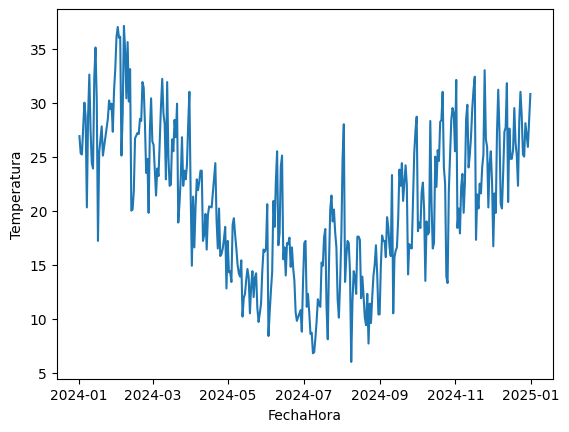

In [59]:
sns.lineplot(df, x="FechaHora", y="Temperatura")